# Exploratory Data Analysis

#### Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency

#### Reading the Raw Dataset

In [2]:
data_df = pd.read_excel("../data/Telco_customer_churn.xlsx")
print("Data Shape :", data_df.shape)
data_df.head()

Data Shape : (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
data_summary = pd.DataFrame({
    "unique_count": data_df.nunique(),
    "null": data_df.isna().sum(),
    "dtype": data_df.dtypes
})
data_summary

,unique_count,null,dtype
CustomerID,7043,0,str
Count,1,0,int64
Country,1,0,str
State,1,0,str
City,1129,0,str
Zip Code,1652,0,int64
Lat Long,1652,0,str
Latitude,1652,0,float64
Longitude,1651,0,float64
Gender,2,0,str


#### Convert "Total Charges" to numeric type

In [4]:
data_df['Total Charges'] = pd.to_numeric(data_df['Total Charges'], errors='coerce')
data_df["Total Charges"].isna().sum()

np.int64(11)

11 null values have been introduced due to this conversion.

In [5]:
data_df[data_df["Total Charges"].isna()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


For rows with Total Charges as empty string (before conversion) / NaN (after conversion), the Tenure Months is 0. Thus, we can fill these null values with 0, which is logically consistent.

In [6]:
data_df.fillna({'Total Charges': 0}, inplace=True)
data_df["Total Charges"].isna().sum()

np.int64(0)

#### Dropping Irrelevant Columns

The "Churn Reason" column is dropped as most of its fields are empty.

In [7]:
data_df.drop("Churn Reason", axis=1, inplace=True)
print("Data Shape :", data_df.shape)

Data Shape : (7043, 32)


Columns with a single value are dropped.

In [8]:
drop_columns = data_df.columns[data_df.nunique() <= 1]
print("Columns containing a single value:", drop_columns)
data_df.drop(columns=drop_columns, inplace=True)
print("Data Shape :", data_df.shape)

Columns containing a single value: Index(['Count', 'Country', 'State'], dtype='str')
Data Shape : (7043, 29)


"Lat Long" is dropped as "Latitude" and "Longitude" are already present in the dataset.

"Churn Value" and "Churn Score" carry the same meaning.

In [9]:
data_df.drop(columns=["Lat Long", "Churn Label", "Churn Score"], inplace=True)
print("Data Shape :", data_df.shape)

Data Shape : (7043, 26)


"CustomerID" is dropped as it has no predictive power.

In [10]:
data_df.drop("CustomerID", axis=1, inplace=True)
data_df.shape

(7043, 25)

"City" is dropped as every row in the dataset contains a different city.

In [11]:
data_df.drop("City", axis=1, inplace=True)
data_df.shape

(7043, 24)

In [12]:
numeric_features = [feature for feature in list(data_df.columns) if feature in list(data_df.describe().columns)]
print("Numeric Features :", numeric_features)
categorical_features = [feature for feature in list(data_df.columns) if feature not in list(data_df.describe().columns)]
print("Categorical Features :", categorical_features)

Numeric Features : ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']
Categorical Features : ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [13]:
numeric_features.remove("Churn Value") # Not a feature
print(numeric_features)

['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']


#### Investigating Collinearity for originally Numerical Features

In [14]:
data_df[numeric_features + ["Churn Value"]].corr()

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Value
Zip Code,1.000000,0.895743,-0.784271,0.001041,-0.004596,-0.000884,-0.003562,0.003346
Latitude,0.895743,1.000000,-0.876779,-0.001631,-0.019899,-0.009944,0.000886,-0.003384
Longitude,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.008876,0.000485,0.004594
Tenure Months,0.001041,-0.001631,-0.001678,1.000000,0.247900,0.826178,0.396406,-0.352229
Monthly Charges,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.651174,0.098693,0.193356
Total Charges,-0.000884,-0.009944,0.008876,0.826178,0.651174,1.000000,0.342091,-0.198324
CLTV,-0.003562,0.000886,0.000485,0.396406,0.098693,0.342091,1.000000,-0.127463
Churn Value,0.003346,-0.003384,0.004594,-0.352229,0.193356,-0.198324,-0.127463,1.000000


In [15]:
vif = pd.DataFrame()
vif['feature'] = numeric_features
vif['VIF'] = [variance_inflation_factor(data_df[numeric_features].values, i) for i in range(data_df[numeric_features].shape[1])]
vif

,feature,VIF
0,Zip Code,6846.617771
1,Latitude,396.580354
2,Longitude,6323.040958
3,Tenure Months,16.264236
4,Monthly Charges,18.142897
5,Total Charges,19.160602
6,CLTV,17.614996


The Variance Inflation Factor (VIF) for Geographic features such as "Zip Code", "Latitude" and "Longitude" are severly high as they are different representations of the same location. Also, they have nearly zero correlation with "Churn Label". Hence, these features can be dropped.

In [16]:
numeric_features.remove('Zip Code')
numeric_features.remove('Latitude')
numeric_features.remove('Longitude')
print("Numeric Features :", numeric_features)
data_df.drop(columns=['Zip Code', 'Latitude', 'Longitude'], inplace=True)
print("Data Shape :", data_df.shape)

Numeric Features : ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
Data Shape : (7043, 21)


The features "Tenure Months", "Monthly Charges", "Total Charges" and "CLTV" need to be investigated further.

In [17]:
vif = pd.DataFrame()
vif['feature'] = numeric_features
vif['VIF'] = [variance_inflation_factor(data_df[numeric_features].values, i) for i in range(data_df[numeric_features].shape[1])]
vif

,feature,VIF
0,Tenure Months,12.685583
1,Monthly Charges,9.653151
2,Total Charges,12.582094
3,CLTV,9.368722


"Total Charges" is highly correlated to "Tenure Months" and "Monthly Charges". This is in line with the fact that the Total Charge is approximately the product of the Monthly Charges and the Tenure Months. Hence, it needs to be dropped.

In [18]:
numeric_features.remove("Total Charges")
print("Numeric Features :", numeric_features)
data_df.drop("Total Charges", axis=1, inplace=True)
print("Data Shape :", data_df.shape)

Numeric Features : ['Tenure Months', 'Monthly Charges', 'CLTV']
Data Shape : (7043, 20)


"Tenure Months" also has a high VIF value. But is an independent feature that cannot be decomposed into simpler independent components, unlike CLTV which is derived from "Tenure Months", "Monthly Charges", even churn and revenue assumptions. Thus, higher VIF for "Tenure Months" is attributed to its ability to explain derived features.

In [19]:
numeric_features.remove("CLTV")
print("Numeric Features :", numeric_features)
data_df.drop("CLTV", axis=1, inplace=True)
print("Data Shape :", data_df.shape)

Numeric Features : ['Tenure Months', 'Monthly Charges']
Data Shape : (7043, 19)


#### Investigating Collinearity for originally Categorical Features

In [20]:
def cramers_v(x, y):
    """
    Cramer's V is used to measure the strength of association between two categorical variables.
    Parameters:
        x : First Categorical Variable (Pandas Series)
        y : Second Categorical Variable (Pandas Series)
    Return:
        Cramer's V value (float) between 0 (no association) and 1 (perfect association).
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

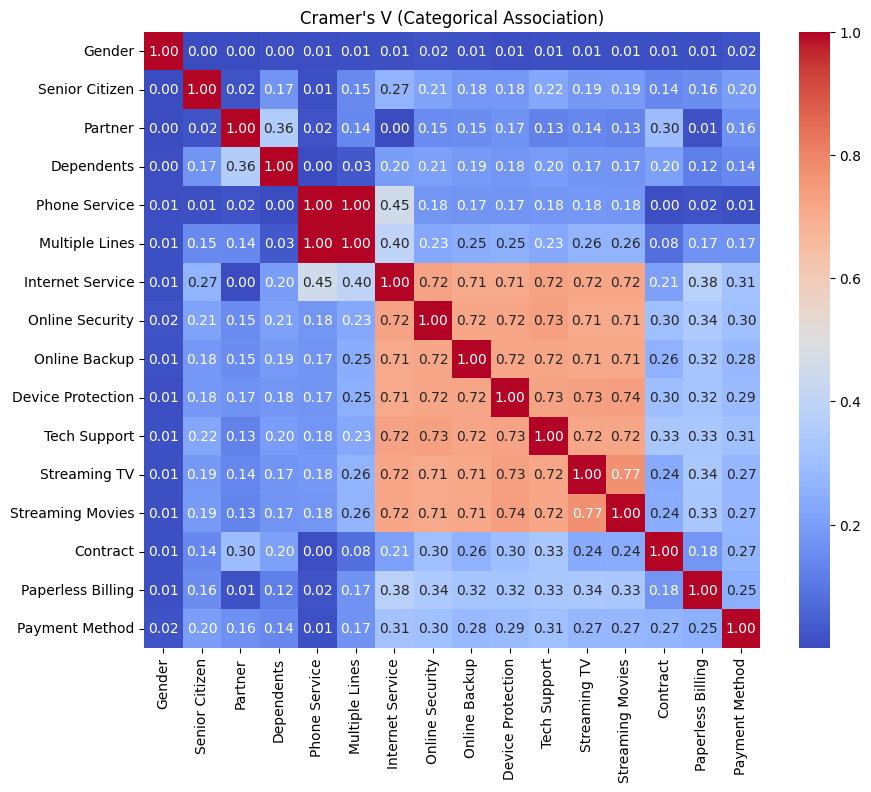

In [21]:
cramers_matrix = pd.DataFrame(index=categorical_features, columns=categorical_features)

for i in categorical_features:
    for j in categorical_features:
        cramers_matrix.loc[i, j] = cramers_v(data_df[i], data_df[j])

cramers_matrix = cramers_matrix.astype(float)

plt.figure(figsize=(10,8))
sns.heatmap(
    cramers_matrix,
    annot = True,
    square = True,
    fmt = ".2f",
    cmap = 'coolwarm'
)
plt.title("Cramer's V (Categorical Association)")
plt.show()

"Phone Service" and "Multiple Lines" exhibit perfect association. Hence, one of them can be dropped.

In [22]:
categorical_features.remove("Multiple Lines")
print("Categorical Features :", categorical_features)
data_df.drop("Multiple Lines", axis=1, inplace=True)
print("Data Shape :", data_df.shape)

Categorical Features : ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Data Shape : (7043, 18)


"Internet Service", "Online Security", "Online Backup", "Device Protection", "Tech Support", "Streaming TV" and "Streaming Movies" are highly correlated. This is in line with the fact that these additional services will only be used by customers having internet connectivity.

In [23]:
categorical_features.remove("Online Security")
categorical_features.remove("Online Backup")
categorical_features.remove("Device Protection")
categorical_features.remove("Tech Support")
categorical_features.remove("Streaming TV")
categorical_features.remove("Streaming Movies")
print("Categorical Features :", categorical_features)
data_df.drop(columns=["Online Security", "Online Backup", "Device Protection", "Tech Support", "Streaming TV", "Streaming Movies"], inplace=True)
print("Data Shape :", data_df.shape)

Categorical Features : ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Internet Service', 'Contract', 'Paperless Billing', 'Payment Method']
Data Shape : (7043, 12)


#### Data Insights

In [24]:
data_df["Churn Value"].value_counts(normalize=True)

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

The dataset illustrates an imbalanced distribution, where the Not-Churn to Churn ratio is approximately 3:1. This class imbalance could induce bias in the prediction model.

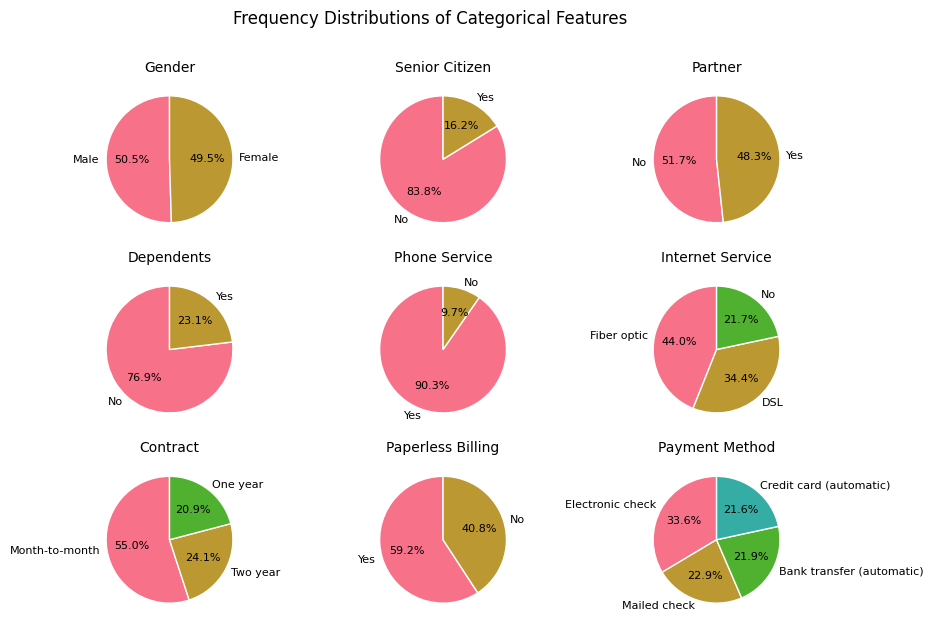

In [25]:
palette = sns.color_palette("husl")

fig, axes = plt.subplots(3, 3, figsize = (10, 7))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    counts = data_df[col].value_counts()
    axes[i].pie(
        counts,
        labels = counts.index,
        autopct = '%1.1f%%',
        startangle = 90,
        colors = palette,
        textprops = {'fontsize': 8},
        wedgeprops = dict(edgecolor = 'white', linewidth = 1)
    )
    axes[i].set_title(col, fontsize = 10)

plt.suptitle("Frequency Distributions of Categorical Features")
plt.show()

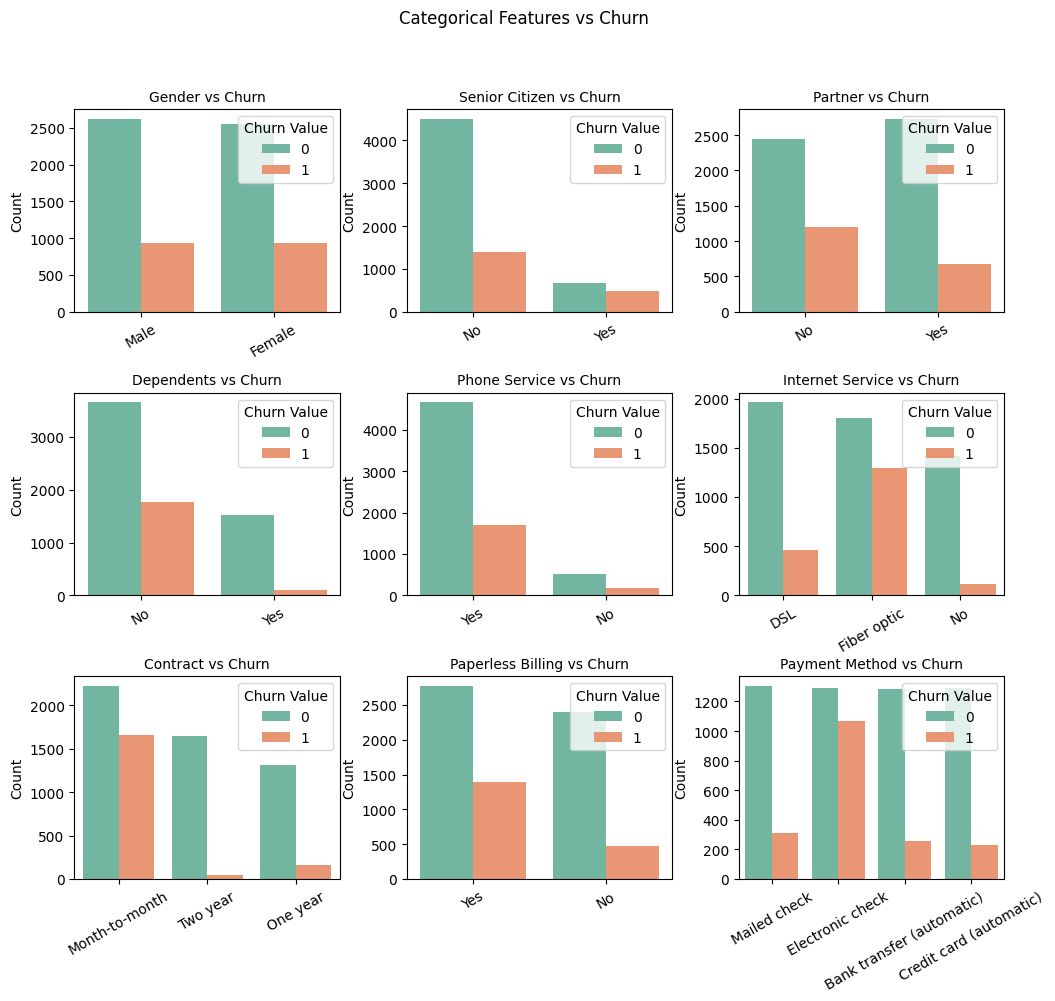

In [26]:
palette = sns.color_palette("Set2", 2)

fig, axes = plt.subplots(3, 3, figsize = (12, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(
        x = col,
        hue = 'Churn Value',
        data = data_df,
        ax = axes[i],
        palette = palette
    )
    axes[i].set_title(f'{col} vs Churn', fontsize = 10)
    axes[i].tick_params(axis = 'x', rotation = 30)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.suptitle("Categorical Features vs Churn")
plt.subplots_adjust(wspace = 0.25, hspace = 0.4)
plt.show()

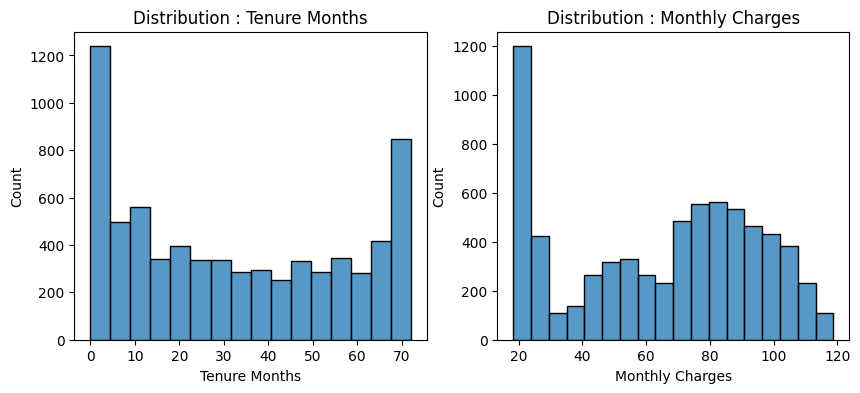

In [27]:
fig, ax = plt.subplots(nrows = 1, ncols = len(numeric_features), figsize = (10, 4))
for i in range(len(numeric_features)):
    plt.subplot(1, 2, i + 1)
    sns.histplot(data_df[numeric_features[i]])
    title = 'Distribution : ' + numeric_features[i]
    plt.title(title)
plt.show()

"Tenure Months" demonstrates a bi-modal distribution pattern with peaks at 0 and 70, highlighting the presence of both short and long term customers.
"Monthly Charges" have significant frequencies around 20, 50 and 80, indicating three pricing bands.

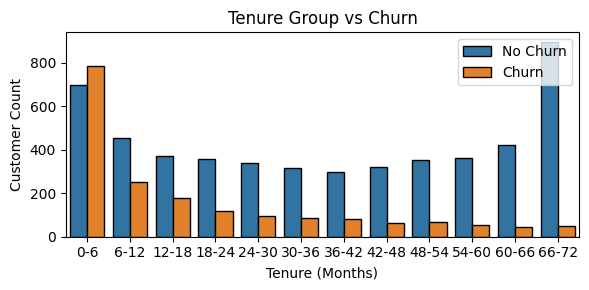

In [ ]:
tenure_groups = pd.cut(
    data_df['Tenure Months'],
    bins = [0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72],
    labels = ['0-6', '6-12', '12-18', '18-24', '24-30', '30-36', '36-42', '42-48', '48-54', '54-60', '60-66', '66-72'],
    include_lowest = True
)

plt.figure(figsize = (6, 3))
sns.countplot(
    x = tenure_groups,
    hue = data_df['Churn Value'],
    edgecolor = 'black'
)

plt.title('Tenure Group vs Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Customer Count')
plt.legend(['No Churn', 'Churn'], loc = 'upper right')
plt.tight_layout()
plt.show()

The customers are more likely to churn within the first 6 months. Over time the likelihood of churn reduces significantly.

In [29]:
data_df.to_excel("../data/Telco_customer_churn_cleaned.xlsx")